# Analyse von Boilerplate-Phrasen und Bias im Übersetzungskorpus
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte/Einfache Sprache (LS)

In dieser Untersuchung analysieren wir den Korpus aus `data/corpus/final/` daraufhin, ob systematische Phrasen wie *"Mehr Informationen in Alltagssprache..."*, *"Klicken Sie hier"*, *"Dieser Link führt..."* oder Erwähnungen von Prüfstellen/Forschern (z.B. *"Universität Hildesheim"*, *"Stefan Albers"*) gehäuft in den Zieltexten vorkommen.

Ein solcher Bias in den Trainingsdaten führt dazu, dass generative seq2seq-Modelle diese Phrasen am Ende oder allgemein im Text halluzinieren, was in der qualitativen Analyse der Webanwendung beobachtet wurde.

In [7]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set project root
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. Laden des Korpus
Wir laden alle JSON-Dateien aus `data/corpus/final/` und extrahieren die Quelltexte (AS) sowie Zieltexte (LS) zusammen mit ihrer Quelle.

In [8]:
json_files = glob.glob("data/corpus/4_normalized_clean/*.json")
all_pairs = []

for file_path in json_files:
    source_name = os.path.basename(file_path).replace("_articles.json", "")
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    pairs = data.get("pairs", [])
    for pair in pairs:
        all_pairs.append({
            "source": source_name,
            "ls_url": pair.get("ls_url", ""),
            "as_url": pair.get("as_url", ""),
            "ls_text": pair.get("ls_text", ""),
            "as_text": pair.get("as_text", ""),
            "ls_tokens": pair.get("ls_tokens", 0),
            "as_tokens": pair.get("as_tokens", 0)
        })

df = pd.DataFrame(all_pairs)
print(f"Gesamtzahl der Artikelpaare geladen: {len(df)}")
df.groupby("source").size().reset_index(name="anzahl_artikel")

Gesamtzahl der Artikelpaare geladen: 1476


,source,anzahl_artikel
0,apotheken,157
1,behindertenbeauftragter,51
2,brandeins,18
3,hamburg,56
4,hannover,796
5,koeln,38
6,main_taunus,34
7,mdr,227
8,sozialpolitik,14
9,stuttgart,39


## 2. Definition der Boilerplate-Phrasen und Muster
Wir definieren eine Liste von Phrasen, Mustern und Prüfsiegeln, um nachzuweisen, wo und wie oft diese vorkommen.

In [9]:
phrases_to_check = {
    "Mehr Informationen": ["mehr informationen", "mehr infos", "weitere informationen"],
    "Alltagssprache": ["alltagssprache", "alltags-sprache"],
    "Klicken Sie": ["klicken sie", "klick auf"],
    "Hier finden Sie": ["hier finden sie", "hier gibt es"],
    "Achtung/Wichtig": ["achtung:", "wichtig:"],
    "Link-Warnung": ["dieser link führt", "aus unserem einfache-sprache-angebot", "nicht mehr in einfacher sprache"],
    "Hildesheim": ["hildesheim", "forschungsstelle leichte sprache"],
    "Stefan Albers": ["stefan albers", "atelier fleetinsel"],
    "Inclusion Europe": ["inclusion europe", "easy-to-read logo"],
    "Prüfung/Umsatz": ["geprüft", "prüfung", "prüfer", "übersetzt von", "institut für leichte sprache"]
}

# Erstelle Spalten für jede Phrasengruppe im DataFrame
for category, patterns in phrases_to_check.items():
    df[category] = df["ls_text"].apply(lambda x: any(pattern in x.lower() for pattern in patterns))

# Hat der Artikel mindestens eine Boilerplate-Phrase?
df["has_any_boilerplate"] = df[list(phrases_to_check.keys())].any(axis=1)
print(f"Anteil an Artikeln mit mindestens einer Boilerplate-Phrase: {df['has_any_boilerplate'].mean():.2%}")

Anteil an Artikeln mit mindestens einer Boilerplate-Phrase: 61.38%


## 3. Analyse nach Quelle
Welche Quelle bringt welche Phrasen mit?

In [10]:
source_boilerplate = df.groupby("source")[list(phrases_to_check.keys()) + ["has_any_boilerplate"]].mean()
source_boilerplate_style = source_boilerplate.style.format("{:.1%}").background_gradient(cmap="Reds", axis=0)
source_boilerplate_style

,Mehr Informationen,Alltagssprache,Klicken Sie,Hier finden Sie,Achtung/Wichtig,Link-Warnung,Hildesheim,Stefan Albers,Inclusion Europe,Prüfung/Umsatz,has_any_boilerplate
source,,,,,,,,,,,
apotheken,29.3%,0.0%,1.9%,7.6%,45.9%,8.9%,0.0%,0.0%,0.0%,7.0%,65.6%
behindertenbeauftragter,11.8%,7.8%,3.9%,11.8%,5.9%,0.0%,2.0%,0.0%,0.0%,5.9%,39.2%
brandeins,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
hamburg,26.8%,0.0%,0.0%,5.4%,32.1%,0.0%,0.0%,7.1%,0.0%,8.9%,58.9%
hannover,65.2%,22.6%,40.1%,0.5%,15.5%,0.0%,8.0%,0.0%,0.0%,1.8%,81.5%
koeln,71.1%,18.4%,7.9%,31.6%,65.8%,0.0%,0.0%,0.0%,0.0%,23.7%,89.5%
main_taunus,2.9%,0.0%,5.9%,11.8%,0.0%,0.0%,0.0%,0.0%,0.0%,2.9%,17.6%
mdr,1.3%,0.0%,0.0%,0.0%,1.3%,0.0%,0.0%,0.0%,0.0%,6.6%,8.8%
sozialpolitik,7.1%,0.0%,0.0%,0.0%,7.1%,0.0%,0.0%,0.0%,0.0%,0.0%,14.3%


## 4. Visualisierung der Ergebnisse

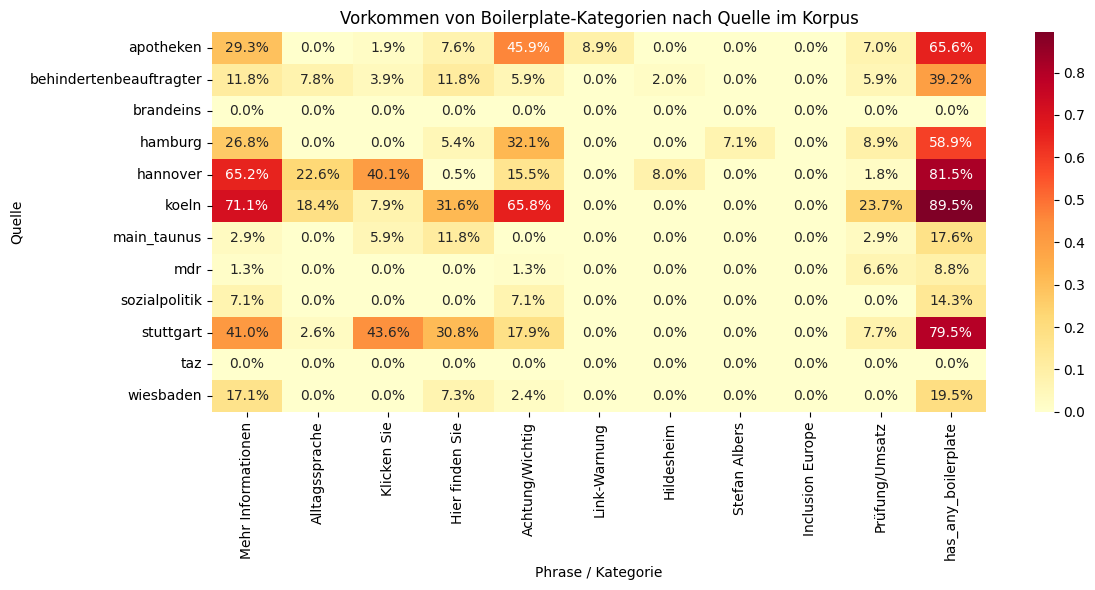

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(source_boilerplate, annot=True, fmt=".1%", cmap="YlOrRd", cbar=True)
plt.title("Vorkommen von Boilerplate-Kategorien nach Quelle im Korpus")
plt.ylabel("Quelle")
plt.xlabel("Phrase / Kategorie")
plt.tight_layout()
plt.show()

## 5. Konkrete Beispiele
Lassen Sie uns ein paar Beispiele anzeigen, wie diese Boilerplates am Ende der Texte aussehen.

In [12]:
for source in df["source"].unique():
    sub = df[(df["source"] == source) & df["has_any_boilerplate"]]
    if not sub.empty:
        print("=" * 80)
        print(f"BEISPIEL AUS QUELLE: {source.upper()}")
        print("=" * 80)
        sample_text = sub.iloc[0]["ls_text"]
        # Zeige die letzten 600 Zeichen des Beispiel-LS-Textes
        print("... " + sample_text[-600:])
        print("\n")

BEISPIEL AUS QUELLE: BEHINDERTENBEAUFTRAGTER
... aben. Er hat Kontakt zu Verbänden und Organisationen und Selbst-Hilfe-Gruppen. Grenzen der Beratung Der oder die Beauftragte darf den Behörden nicht sagen, was die tun müssen. Und darf auch in rechtlichen Sachen nicht beraten. Das dürfen nur Rechtsanwält*innen. Oder besondere Organisationen. Der oder die Beauftragte ist nicht für die Bundes-Länder zuständig. Das machen die Landes-Behinderten-Beauftragten. Der oder die Beauftragte kann auch keine Projekte mit Geld unterstützen. Auch Einzel-Personen können nicht unterstützt werden. Downloads Hier finden Sie die Ansprechpartner der Bundes-Länder.


BEISPIEL AUS QUELLE: STUTTGART
...  Link: Sucht-Prävention an Schulen () Sucht-Prävention im Alter Sucht kennt keine Alters-Grenzen. Junge Menschen können süchtig werden. Und alte Menschen können süchtig werden. Zum Beispiel von Alkohol und Zigaretten. Oder von Medikamenten. Das kann auch bei älteren Menschen gesundheitliche Schäden machen. Es gi